# Northstar Connect — Sessions 1–10 Assessment

End-to-end analysis: data audit → cleaning → train / validation / final-test split → EDA → feature engineering → revenue regression → churn classification and campaign threshold → cross-validation → pipeline tuning → customer segmentation → business recommendations → reproducibility check.

Run the notebook from top to bottom with a fresh kernel. All paths are relative and the random seed is `RANDOM_STATE = 42`.


## 1. Business Understanding

Northstar Connect (a fictional UK telecom) wants to use its customer snapshot to support three connected decisions.

| Business question | ML problem | Target | Main metrics |
|---|---|---|---|
| Revenue planning: how much will a customer generate in the next 90 days? | Regression | `revenue_next_90d_gbp` | MAE, RMSE, R² |
| Churn prevention: who is at risk of leaving in the next 90 days, and whom should we contact? | Binary classification + threshold choice | `churned_next_90d` | ROC-AUC, precision, recall, F1, confusion matrix, expected campaign net value |
| Customer strategy: are there useful customer segments? | Clustering (unsupervised) | none | silhouette score, segment profiles |

**Stakeholders:** Head of Customer Retention, Commercial Planning Manager, Customer Experience Director, CRM Campaign Team, Data / AI Team.

**Campaign assumptions (from `BUSINESS_CASE.md`):** contact at most 10% of customers; £6 per contact; £75 value per successful retention; 30% of contacted would-be churners are retained.

`expected_net_value = (true_positive_contacts × 0.30 × £75) − (all_contacts × £6)`

**Why accuracy is not the main churn metric:** only about 10% of customers churn, so a model that predicts "nobody churns" is about 90% accurate and useless. Ranking quality (ROC-AUC) and the campaign economics at the chosen threshold matter more.

**Prediction-time thinking and leakage risks**

- `retention_case_status` is excluded from the models. A retention case is opened and closed around the churn event, so it may not be known at the time of prediction.
- `record_id` and `customer_id` are identifiers, not predictors.
- `snapshot_date` and `join_date` are not used directly; tenure is already available as `tenure_months`.
- The two targets are never used as inputs.
- Imputation and encoding are learned inside Scikit-learn pipelines fitted on training data only.
- The final test set is used once, after the model and threshold are fixed.

**Assumptions and risks:** the snapshot is treated as one row per customer; the campaign assumptions are simplified; relationships found here are associations, not causes.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42


## 2. Data Loading

In [2]:
# Relative paths only. The notebook works whether Jupyter is started in the
# project root (data/ next to this notebook) or in a sub-folder (data/ one level up).
DATA_FILE = Path("data") / "raw" / "northstar_connect_customer_snapshot.csv"
DATA_PATH = next(
    (base / DATA_FILE for base in (Path("."), Path("..")) if (base / DATA_FILE).exists()),
    DATA_FILE
)
assert DATA_PATH.exists(), f"Dataset not found: {DATA_PATH.resolve()}"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (1000000, 31)


,record_id,customer_id,snapshot_date,join_date,region,plan_tier,contract_type,payment_method,sales_channel,age,...,support_calls_90d,complaints_90d,billing_disputes_90d,late_payments_12m,satisfaction_score,usage_change_3m_pct,device_count,retention_case_status,churned_next_90d,revenue_next_90d_gbp
0,R000000001,C000000001,2025-06-30,2021-02-21,London,Essential,Monthly,Bank Transfer,Website,36,...,2,0,0,1,7.46,-16.12,4,none,1,62.93
1,R000000002,C000000002,2026-06-30,2023-06-16,North West,Essential,Monthly,Card,Call Centre,49,...,0,0,0,0,9.44,-22.96,5,saved,0,114.10
2,R000000003,C000000003,2025-07-31,2023-06-12,Yorkshire,Plus,Monthly,Bank Transfer,Retail Store,29,...,0,0,0,0,10.00,16.07,2,none,0,120.86
3,R000000004,C000000004,2025-09-30,2024-12-04,South East,Essential,Monthly,Card,Website,53,...,0,0,0,1,8.46,-36.83,5,none,0,81.58
4,R000000005,C000000005,2025-04-30,2023-05-11,Scotland,Essential,Monthly,Card,Website,23,...,0,0,0,1,8.47,21.07,3,none,0,98.41


## 3. Data Quality Audit

In [3]:
# ==========================================
# DATA QUALITY AUDIT
# ==========================================

print("DATASET SHAPE")
print(df.shape)

print("\nDATA TYPES")
display(df.dtypes.to_frame("dtype"))

print("\nMISSING VALUES")
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame("missing_count"))

print("\nEXACT DUPLICATE ROWS")
print(df.duplicated().sum())

print("\nUNIQUE VALUES")
display(df.nunique(dropna=False).sort_values().to_frame("unique_count"))

print("\nNUMERICAL SUMMARY")
display(df.describe().T)

print("\nCATEGORICAL VALUES")
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    display(
        df[col]
        .astype("string")
        .str.strip()
        .value_counts(dropna=False)
        .head(20)
        .to_frame("count")
    )

DATASET SHAPE
(1000000, 31)

DATA TYPES


,dtype
record_id,object
customer_id,object
snapshot_date,object
join_date,object
region,object
plan_tier,object
contract_type,object
payment_method,object
sales_channel,object
age,int64



MISSING VALUES


,missing_count
satisfaction_score,25103
avg_download_mbps,17979
usage_change_3m_pct,11947
discount_pct,7970
contract_remaining_months,6981
payment_method,5972



EXACT DUPLICATE ROWS


...

,count
payment_method,
Direct Debit,515852
Card,238312
Digital Wallet,138630
Bank Transfer,99231
<NA>,5972
direct debit,1021
BANK TRANSFER,982



--- sales_channel ---


,count
sales_channel,
Website,450592
Retail Store,219760
Call Centre,210254
Partner,119394



--- retention_case_status ---


,count
retention_case_status,
none,751026
saved,90357
open,82644
closure_confirmed,75973


## 4. Data Cleaning Strategy and Train/Test Planning

**Target-independent corrections (applied to the full dataset before splitting)**

- Remove exact duplicate rows.
- Standardise category text (trim spaces, lower case) so that labels such as `London` / `london` become one category.
- Convert `snapshot_date` and `join_date` to dates.
- Set ages below 18 or above 100 to missing.
- Extreme fee, data-usage and latency values are kept, not deleted.

**Learned preprocessing (fitted on training data only, inside pipelines)**

- Median imputation for numerical columns.
- Most-frequent imputation and one-hot encoding for categorical columns.

**Split (seed 42, stratified on churn)**

- 20% final test, sealed until the end.
- The remaining 80% is split again into 80% training and 20% validation.
- Validation is used for model comparison and threshold selection.


In [4]:
# ==========================================
# DATA CLEANING AND MODELLING SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

# ------------------------------------------
# 1. DATA CLEANING
# ------------------------------------------

df_clean = df.copy()

before = len(df_clean)
df_clean = df_clean.drop_duplicates()
duplicates_removed = before - len(df_clean)

categorical_cols = [
    "region",
    "plan_tier",
    "contract_type",
    "payment_method",
    "sales_channel",
    "retention_case_status"
]

for col in categorical_cols:
    df_clean[col] = (
        df_clean[col]
        .astype("string")
        .str.strip()
        .str.lower()
    )

df_clean["snapshot_date"] = pd.to_datetime(df_clean["snapshot_date"])
df_clean["join_date"] = pd.to_datetime(df_clean["join_date"])

invalid_age = (df_clean["age"] < 18) | (df_clean["age"] > 100)
invalid_age_count = invalid_age.sum()

df_clean.loc[invalid_age, "age"] = np.nan

print("DATA CLEANING")
print("Original rows:", len(df))
print("Duplicates removed:", duplicates_removed)
print("Cleaned rows:", len(df_clean))
print("Invalid ages converted to missing:", invalid_age_count)

print("\nRemaining missing values:")
display(
    df_clean.isna().sum()
    .sort_values(ascending=False)
    .loc[lambda x: x > 0]
    .to_frame("missing_count")
)

# Concise before / after data-quality summary (full dataset)
label_cols = ["region", "plan_tier", "payment_method"]

data_quality_summary = pd.DataFrame(
    {
        "Before cleaning": [
            len(df),
            int(df.duplicated().sum()),
            int(df.isna().sum().sum()),
            int(((df["age"] < 18) | (df["age"] > 100)).sum()),
            *[int(df[c].nunique(dropna=True)) for c in label_cols]
        ],
        "After cleaning": [
            len(df_clean),
            int(df_clean.duplicated().sum()),
            int(df_clean.isna().sum().sum()),
            int(((df_clean["age"] < 18) | (df_clean["age"] > 100)).sum()),
            *[int(df_clean[c].nunique(dropna=True)) for c in label_cols]
        ]
    },
    index=[
        "Rows",
        "Exact duplicate rows",
        "Missing cells (all columns)",
        "Ages below 18 or above 100",
        *[f"Distinct labels: {c}" for c in label_cols]
    ]
)

print("\nBEFORE / AFTER DATA-QUALITY SUMMARY")
display(data_quality_summary)


# ------------------------------------------
# 2. TARGETS AND PREDICTORS
# ------------------------------------------

y_churn = df_clean["churned_next_90d"]
y_revenue = df_clean["revenue_next_90d_gbp"]

excluded_columns = [
    "record_id",
    "customer_id",
    "retention_case_status",
    "churned_next_90d",
    "revenue_next_90d_gbp",
    "snapshot_date",
    "join_date"
]

X = df_clean.drop(columns=excluded_columns)

print("\nMODELLING DATASET")
print("Predictor columns:", X.shape[1])
print("Duplicated customer IDs:", df_clean["customer_id"].duplicated().sum())


# ------------------------------------------
# 3. FINAL TEST SPLIT
# ------------------------------------------
# The final test set is now sealed.
# We will NOT use it for model selection,
# feature selection, tuning or threshold selection.

(
    X_development,
    X_final_test,
    y_churn_development,
    y_churn_final_test,
    y_revenue_development,
    y_revenue_final_test
) = train_test_split(
    X,
    y_churn,
    y_revenue,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_churn
)

print("\nFINAL DATA SPLIT")
print("Development:", X_development.shape)
print("Final test:", X_final_test.shape)

print(
    "Development churn rate:",
    round(y_churn_development.mean(), 4)
)

print(
    "Final test churn rate:",
    round(y_churn_final_test.mean(), 4)
)


# ------------------------------------------
# 4. TRAIN / VALIDATION SPLIT
# ------------------------------------------

(
    X_train,
    X_validation,
    y_churn_train,
    y_churn_validation,
    y_revenue_train,
    y_revenue_validation
) = train_test_split(
    X_development,
    y_churn_development,
    y_revenue_development,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_churn_development
)

print("\nDEVELOPMENT SPLIT")
print("Training:", X_train.shape)
print("Validation:", X_validation.shape)

print(
    "Training churn rate:",
    round(y_churn_train.mean(), 4)
)

print(
    "Validation churn rate:",
    round(y_churn_validation.mean(), 4)
)


DATA CLEANING
Original rows: 1000000
Duplicates removed: 5000
Cleaned rows: 995000
Invalid ages converted to missing: 245

Remaining missing values:


,missing_count
satisfaction_score,24996
avg_download_mbps,17900
usage_change_3m_pct,11899
discount_pct,7935
contract_remaining_months,6956
payment_method,5941
age,245



BEFORE / AFTER DATA-QUALITY SUMMARY


,Before cleaning,After cleaning
Rows,1000000,995000
Exact duplicate rows,5000,0
Missing cells (all columns),75952,75872
Ages below 18 or above 100,245,0
Distinct labels: region,15,11
Distinct labels: plan_tier,6,3
Distinct labels: payment_method,7,4



MODELLING DATASET
Predictor columns: 24


Duplicated customer IDs: 0



FINAL DATA SPLIT
Development: (796000, 24)
Final test: (199000, 24)
Development churn rate: 0.0992
Final test churn rate: 0.0992



DEVELOPMENT SPLIT
Training: (636800, 24)
Validation: (159200, 24)
Training churn rate: 0.0992
Validation churn rate: 0.0992


## 5. Exploratory Data Analysis

EDA is carried out on the training split only.


EDA rows (training split): 636800

A. CUSTOMER CHARACTERISTICS AND CHURN

Churn rate by plan tier:


,churn_rate_pct
plan_tier,
essential,9.95
plus,9.91
ultra,9.84



Churn rate by contract type:


,churn_rate_pct
contract_type,
12-month,7.93
24-month,5.58
monthly,14.87



B. SERVICE QUALITY AND CHURN


...

,count,mean,median
contract_type,,,
12-month,216946,112.86,110.41
24-month,177552,102.50,99.78
monthly,242302,122.06,119.20



E. PLAN TIER AND CHURN / REVENUE


,customers,churn_rate,avg_revenue
plan_tier,,,
essential,269825,9.95,83.69
plus,240575,9.91,120.16
ultra,126400,9.84,164.32



F. CONTRACT TYPE AND CHURN / REVENUE


,customers,churn_rate,avg_revenue
contract_type,,,
12-month,216946,7.93,112.86
24-month,177552,5.58,102.50
monthly,242302,14.87,122.06


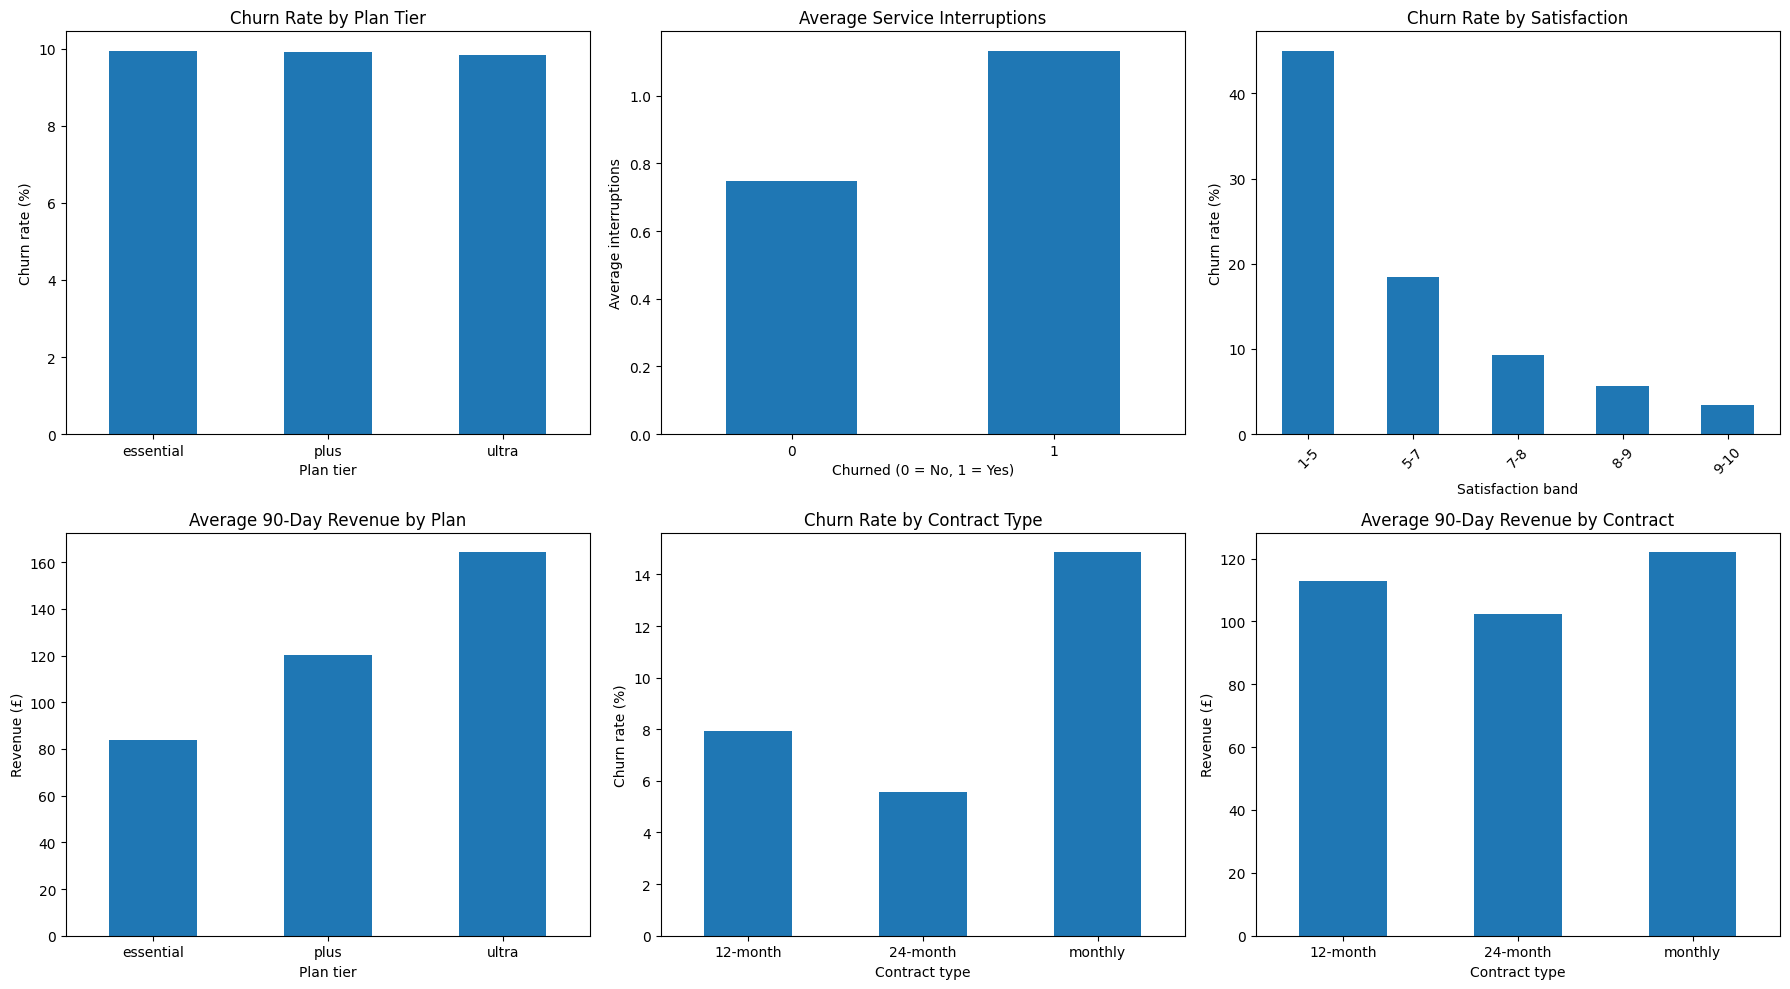

In [5]:
# ==========================================
# 5. EXPLORATORY DATA ANALYSIS
# ==========================================
# EDA uses the TRAINING split created in Section 4 only.
# The validation and final test sets are not inspected here,
# and the split is NOT recreated in this cell.

eda = X_train.copy()

eda["churned_next_90d"] = y_churn_train.values
eda["revenue_next_90d_gbp"] = y_revenue_train.values

print("EDA rows (training split):", len(eda))


# ==========================================
# EDA QUESTION A
# Customer characteristics and churn
# ==========================================

print("\n==========================================")
print("A. CUSTOMER CHARACTERISTICS AND CHURN")
print("==========================================")

print("\nChurn rate by plan tier:")
display(
    eda.groupby("plan_tier")["churned_next_90d"]
       .mean()
       .mul(100)
       .round(2)
       .to_frame("churn_rate_pct")
)

print("\nChurn rate by contract type:")
display(
    eda.groupby("contract_type")["churned_next_90d"]
       .mean()
       .mul(100)
       .round(2)
       .to_frame("churn_rate_pct")
)


# ==========================================
# EDA QUESTION B
# Service quality and churn
# ==========================================

print("\n==========================================")
print("B. SERVICE QUALITY AND CHURN")
print("==========================================")

service_cols = [
    "service_interruptions_90d",
    "outage_minutes_90d",
    "support_calls_90d",
    "complaints_90d",
    "billing_disputes_90d"
]

display(
    eda.groupby("churned_next_90d")[service_cols]
       .mean()
       .T
       .rename(columns={
           0: "non_churners",
           1: "churners"
       })
       .round(2)
)


# ==========================================
# EDA QUESTION C
# Satisfaction and churn
# ==========================================

print("\n==========================================")
print("C. SATISFACTION AND CHURN")
print("==========================================")

eda["satisfaction_band"] = pd.cut(
    eda["satisfaction_score"],
    bins=[0, 5, 7, 8, 9, 10],
    labels=["1-5", "5-7", "7-8", "8-9", "9-10"],
    include_lowest=True
)

display(
    eda.groupby("satisfaction_band", observed=False)["churned_next_90d"]
       .mean()
       .mul(100)
       .round(2)
       .to_frame("churn_rate_pct")
)


# ==========================================
# EDA QUESTION D
# Customer characteristics and revenue
# ==========================================

print("\n==========================================")
print("D. CUSTOMER CHARACTERISTICS AND REVENUE")
print("==========================================")

print("\nRevenue by plan tier:")
display(
    eda.groupby("plan_tier")["revenue_next_90d_gbp"]
       .agg(["count", "mean", "median"])
       .round(2)
)

print("\nRevenue by contract type:")
display(
    eda.groupby("contract_type")["revenue_next_90d_gbp"]
       .agg(["count", "mean", "median"])
       .round(2)
)


# ==========================================
# EDA QUESTION E
# Plan tier and churn / revenue
# ==========================================

print("\n==========================================")
print("E. PLAN TIER AND CHURN / REVENUE")
print("==========================================")

plan_summary = (
    eda.groupby("plan_tier")
       .agg(
           customers=("plan_tier", "size"),
           churn_rate=("churned_next_90d", "mean"),
           avg_revenue=("revenue_next_90d_gbp", "mean")
       )
)

plan_summary["churn_rate"] = plan_summary["churn_rate"] * 100

display(plan_summary.round(2))


# ==========================================
# EDA QUESTION F
# Contract type and churn / revenue
# ==========================================

print("\n==========================================")
print("F. CONTRACT TYPE AND CHURN / REVENUE")
print("==========================================")

contract_summary = (
    eda.groupby("contract_type")
       .agg(
           customers=("contract_type", "size"),
           churn_rate=("churned_next_90d", "mean"),
           avg_revenue=("revenue_next_90d_gbp", "mean")
       )
)

contract_summary["churn_rate"] = contract_summary["churn_rate"] * 100

display(contract_summary.round(2))


# ==========================================
# EDA VISUALS
# ==========================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# A. Plan tier vs churn
(
    eda.groupby("plan_tier")["churned_next_90d"]
       .mean()
       .mul(100)
       .plot(kind="bar", ax=axes[0, 0])
)
axes[0, 0].set_title("Churn Rate by Plan Tier")
axes[0, 0].set_ylabel("Churn rate (%)")
axes[0, 0].set_xlabel("Plan tier")
axes[0, 0].tick_params(axis="x", rotation=0)

# B. Service interruptions vs churn
(
    eda.groupby("churned_next_90d")["service_interruptions_90d"]
       .mean()
       .plot(kind="bar", ax=axes[0, 1])
)
axes[0, 1].set_title("Average Service Interruptions")
axes[0, 1].set_ylabel("Average interruptions")
axes[0, 1].set_xlabel("Churned (0 = No, 1 = Yes)")
axes[0, 1].tick_params(axis="x", rotation=0)

# C. Satisfaction vs churn
(
    eda.groupby("satisfaction_band", observed=False)["churned_next_90d"]
       .mean()
       .mul(100)
       .plot(kind="bar", ax=axes[0, 2])
)
axes[0, 2].set_title("Churn Rate by Satisfaction")
axes[0, 2].set_ylabel("Churn rate (%)")
axes[0, 2].set_xlabel("Satisfaction band")
axes[0, 2].tick_params(axis="x", rotation=45)

# D. Plan tier vs revenue
(
    eda.groupby("plan_tier")["revenue_next_90d_gbp"]
       .mean()
       .plot(kind="bar", ax=axes[1, 0])
)
axes[1, 0].set_title("Average 90-Day Revenue by Plan")
axes[1, 0].set_ylabel("Revenue (£)")
axes[1, 0].set_xlabel("Plan tier")
axes[1, 0].tick_params(axis="x", rotation=0)

# E. Contract type vs churn
(
    eda.groupby("contract_type")["churned_next_90d"]
       .mean()
       .mul(100)
       .plot(kind="bar", ax=axes[1, 1])
)
axes[1, 1].set_title("Churn Rate by Contract Type")
axes[1, 1].set_ylabel("Churn rate (%)")
axes[1, 1].set_xlabel("Contract type")
axes[1, 1].tick_params(axis="x", rotation=0)

# F. Contract type vs revenue
(
    eda.groupby("contract_type")["revenue_next_90d_gbp"]
       .mean()
       .plot(kind="bar", ax=axes[1, 2])
)
axes[1, 2].set_title("Average 90-Day Revenue by Contract")
axes[1, 2].set_ylabel("Revenue (£)")
axes[1, 2].set_xlabel("Contract type")
axes[1, 2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### EDA observations (training split, 636,800 customers)

- **Plan tier** barely changes churn (9.84% to 9.95%) but strongly orders revenue: about £84 (Essential), £120 (Plus) and £164 (Ultra) over 90 days. Plan tier matters for the revenue model far more than for the churn model.
- **Contract type** shows a clear churn pattern: monthly 14.87%, 12-month 7.93%, 24-month 5.58%.
- **Satisfaction** has the strongest pattern: 45.03% churn in the 1–5 band, falling to 3.40% in the 9–10 band.
- **Service and support:** churners averaged 1.13 interruptions (0.75 for non-churners), 1.11 support calls (0.55) and 0.37 complaints (0.10).
- **Class imbalance:** about 9.9% of customers churn, so accuracy alone is misleading.

These are associations in historical data. They do not prove that any one factor causes churn.


## 6. Feature Engineering

In [6]:
# ==========================================
# 6. FEATURE ENGINEERING
# ==========================================

# Create copies so the original datasets remain unchanged
X_train_fe = X_train.copy()
X_validation_fe = X_validation.copy()
X_final_test_fe = X_final_test.copy()


def create_features(data):
    data = data.copy()

    # --------------------------------------
    # 1. Tenure in years
    # --------------------------------------
    data["tenure_years"] = data["tenure_months"] / 12

    # --------------------------------------
    # 2. Effective monthly fee after discount
    # --------------------------------------
    data["fee_after_discount"] = (
        data["monthly_fee_gbp"] *
        (1 - data["discount_pct"].fillna(0) / 100)
    )

    # --------------------------------------
    # 3. Data usage per device
    # --------------------------------------
    data["data_per_device_gb"] = (
        data["avg_monthly_data_gb"] /
        data["device_count"].replace(0, np.nan)
    )

    # --------------------------------------
    # 4. Combined service issue measure
    # --------------------------------------
    data["service_issue_count"] = (
        data["service_interruptions_90d"].fillna(0)
        + data["complaints_90d"].fillna(0)
        + data["billing_disputes_90d"].fillna(0)
    )

    # --------------------------------------
    # 5. Customer contact intensity
    # --------------------------------------
    data["customer_contact_intensity"] = (
        data["support_calls_90d"].fillna(0)
        + data["complaints_90d"].fillna(0)
    )

    # --------------------------------------
    # 6. Negative usage change
    # --------------------------------------
    data["negative_usage_change"] = (
        data["usage_change_3m_pct"] < 0
    ).astype(int)

    # --------------------------------------
    # 7. High latency flag
    # --------------------------------------
    data["high_latency_flag"] = (
        data["peak_hour_latency_ms"] > 100
    ).astype(int)

    # --------------------------------------
    # 8. Recent outage flag
    # --------------------------------------
    data["recent_outage_flag"] = (
        data["service_interruptions_90d"] > 0
    ).astype(int)

    return data


# Apply identical feature engineering to all three datasets
X_train_fe = create_features(X_train_fe)
X_validation_fe = create_features(X_validation_fe)
X_final_test_fe = create_features(X_final_test_fe)


# --------------------------------------
# Report results
# --------------------------------------

print("Original number of predictors:", X_train.shape[1])
print("New number of predictors:", X_train_fe.shape[1])

new_features = [
    "tenure_years",
    "fee_after_discount",
    "data_per_device_gb",
    "service_issue_count",
    "customer_contact_intensity",
    "negative_usage_change",
    "high_latency_flag",
    "recent_outage_flag"
]

print("\nNew features created:")
for feature in new_features:
    print("-", feature)

print("\nTraining feature matrix:", X_train_fe.shape)
print("Validation feature matrix:", X_validation_fe.shape)
print("Final test feature matrix:", X_final_test_fe.shape)

print("\nNew feature summary:")
display(X_train_fe[new_features].describe().T.round(2))

Original number of predictors: 24
New number of predictors: 32

New features created:
- tenure_years
- fee_after_discount
- data_per_device_gb
- service_issue_count
- customer_contact_intensity
- negative_usage_change
- high_latency_flag
- recent_outage_flag

Training feature matrix: (636800, 32)
Validation feature matrix: (159200, 32)
Final test feature matrix: (199000, 32)

New feature summary:


,count,mean,std,min,25%,50%,75%,max
tenure_years,636800.0,2.99,2.05,0.08,1.42,2.50,4.08,10.00
fee_after_discount,636800.0,33.84,14.47,10.50,25.15,31.67,41.08,819.83
data_per_device_gb,636800.0,95.78,120.74,7.72,52.65,77.02,114.73,19410.39
service_issue_count,636800.0,1.01,1.09,0.00,0.00,1.00,2.00,11.00
customer_contact_intensity,636800.0,0.74,1.03,0.00,0.00,0.00,1.00,11.00
negative_usage_change,636800.0,0.48,0.50,0.00,0.00,0.00,1.00,1.00
high_latency_flag,636800.0,0.00,0.02,0.00,0.00,0.00,0.00,1.00
recent_outage_flag,636800.0,0.54,0.50,0.00,0.00,1.00,1.00,1.00


## 7. Regression — 90-Day Revenue

In [7]:
# ==========================================
# 7. REGRESSION — 90-DAY REVENUE PREDICTION
# ==========================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ------------------------------------------
# 1. Prepare targets
# ------------------------------------------

y_revenue_train = y_revenue_train.copy()
y_revenue_validation = y_revenue_validation.copy()
y_revenue_final_test = y_revenue_final_test.copy()


# ------------------------------------------
# 2. Create model copies
# ------------------------------------------

X_train_model = X_train_fe.copy()
X_validation_model = X_validation_fe.copy()
X_final_test_model = X_final_test_fe.copy()


# ------------------------------------------
# 3. Identify categorical features
# ------------------------------------------

categorical_features = [
    col for col in X_train_model.columns
    if (
        pd.api.types.is_string_dtype(X_train_model[col])
        or isinstance(
            X_train_model[col].dtype,
            pd.CategoricalDtype
        )
        or X_train_model[col].dtype == "object"
    )
]


# Everything else is treated as numerical
numerical_features = [
    col for col in X_train_model.columns
    if col not in categorical_features
]


print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))

print("\nCategorical columns:")
for col in categorical_features:
    print("-", col)


# ------------------------------------------
# 4. Make data types sklearn-safe
# ------------------------------------------

# Categorical columns:
# Convert to ordinary object dtype and replace pandas
# pd.NA with NumPy np.nan.

for df in [
    X_train_model,
    X_validation_model,
    X_final_test_model
]:

    for col in categorical_features:

        df[col] = df[col].astype(object)

        df[col] = df[col].where(
            pd.notna(df[col]),
            np.nan
        )


# Numerical columns:
# Force numeric representation and convert any invalid
# or missing values to np.nan.

for df in [
    X_train_model,
    X_validation_model,
    X_final_test_model
]:

    for col in numerical_features:

        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )


print("\nNumerical columns:", len(numerical_features))


# ------------------------------------------
# 5. Preprocessing pipelines
# ------------------------------------------

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        ),
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        )
    ]
)


# ------------------------------------------
# 6. Evaluation function
# ------------------------------------------

def evaluate_regression_model(
    name,
    model,
    X_data,
    y_data
):

    predictions = model.predict(X_data)

    mae = mean_absolute_error(
        y_data,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_data,
            predictions
        )
    )

    r2 = r2_score(
        y_data,
        predictions
    )

    return {
        "Model": name,
        "MAE (£)": mae,
        "RMSE (£)": rmse,
        "R²": r2
    }


# ------------------------------------------
# 7. Baseline regression
# ------------------------------------------

baseline_regression = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DummyRegressor(
                strategy="mean"
            )
        )
    ]
)


print("\nTraining baseline regression model...")


baseline_regression.fit(
    X_train_model,
    y_revenue_train
)


baseline_results = evaluate_regression_model(
    "Mean Baseline",
    baseline_regression,
    X_validation_model,
    y_revenue_validation
)


# ------------------------------------------
# 8. HistGradientBoosting regression
# ------------------------------------------

hist_regression = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            HistGradientBoostingRegressor(
                max_iter=150,
                learning_rate=0.08,
                max_leaf_nodes=31,
                l2_regularization=1.0,
                random_state=42
            )
        )
    ]
)


print(
    "Training HistGradientBoosting regression model..."
)


hist_regression.fit(
    X_train_model,
    y_revenue_train
)


hist_results = evaluate_regression_model(
    "HistGradientBoosting",
    hist_regression,
    X_validation_model,
    y_revenue_validation
)


# ------------------------------------------
# 9. Validation comparison
# ------------------------------------------

regression_results = pd.DataFrame(
    [
        baseline_results,
        hist_results
    ]
)


print("\n==========================================")
print("REGRESSION VALIDATION RESULTS")
print("==========================================")


display(
    regression_results.style.format({
        "MAE (£)": "£{:.2f}",
        "RMSE (£)": "£{:.2f}",
        "R²": "{:.4f}"
    })
)


# ------------------------------------------
# 10. Business interpretation
# ------------------------------------------

print("\nBUSINESS INTERPRETATION")


hist_row = regression_results[
    regression_results["Model"]
    == "HistGradientBoosting"
].iloc[0]


print(
    f"The HistGradientBoosting model achieved "
    f"a validation MAE of "
    f"£{hist_row['MAE (£)']:.2f}."
)


print(
    f"The validation RMSE was "
    f"£{hist_row['RMSE (£)']:.2f}."
)


print(
    f"The validation R² was "
    f"{hist_row['R²']:.4f}."
)


print(
    "\nThe final test set has NOT been used "
    "for model selection or evaluation."
)

Categorical features: 5
Numerical features: 27

Categorical columns:
- region
- plan_tier
- contract_type
- payment_method
- sales_channel



Numerical columns: 27

Training baseline regression model...


Training HistGradientBoosting regression model...



REGRESSION VALIDATION RESULTS


,Model,MAE (£),RMSE (£),R²
0,Mean Baseline,£30.76,£37.68,-0.0000
1,HistGradientBoosting,£11.00,£18.10,0.7692



BUSINESS INTERPRETATION
The HistGradientBoosting model achieved a validation MAE of £11.00.
The validation RMSE was £18.10.
The validation R² was 0.7692.

The final test set has NOT been used for model selection or evaluation.


## 8. Classification — 90-Day Churn

Compare candidate models and thresholds using training/validation data or cross-validation. Do not choose the operating threshold on the final test set.

In [8]:
# ==========================================
# 8. CLASSIFICATION — 90-DAY CHURN
# ==========================================

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ------------------------------------------
# 1. Prepare classification data
# ------------------------------------------

X_train_clf = X_train_fe.copy()
X_validation_clf = X_validation_fe.copy()
X_final_test_clf = X_final_test_fe.copy()

y_churn_train = y_churn_train.copy()
y_churn_validation = y_churn_validation.copy()
y_churn_final_test = y_churn_final_test.copy()


# ------------------------------------------
# 2. Identify categorical / numerical columns
# ------------------------------------------

categorical_features_clf = [
    col for col in X_train_clf.columns
    if (
        pd.api.types.is_string_dtype(X_train_clf[col])
        or isinstance(
            X_train_clf[col].dtype,
            pd.CategoricalDtype
        )
        or X_train_clf[col].dtype == "object"
    )
]

numerical_features_clf = [
    col for col in X_train_clf.columns
    if col not in categorical_features_clf
]


print("Categorical features:", len(categorical_features_clf))
print("Numerical features:", len(numerical_features_clf))


# ------------------------------------------
# 3. Make all data sklearn-safe
# ------------------------------------------

for df in [
    X_train_clf,
    X_validation_clf,
    X_final_test_clf
]:

    # Categorical columns
    for col in categorical_features_clf:

        df[col] = df[col].astype(object)

        df[col] = df[col].where(
            pd.notna(df[col]),
            np.nan
        )

    # Numerical columns
    for col in numerical_features_clf:

        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )


# ------------------------------------------
# 4. Classification preprocessing
# ------------------------------------------

categorical_pipeline_clf = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


numerical_pipeline_clf = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)


preprocessor_clf = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_pipeline_clf,
            categorical_features_clf
        ),
        (
            "numerical",
            numerical_pipeline_clf,
            numerical_features_clf
        )
    ]
)


# ------------------------------------------
# 5. Candidate models
# ------------------------------------------

# Baseline:
# predicts the majority class for every customer.

baseline_classifier = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_clf
        ),
        (
            "model",
            DummyClassifier(
                strategy="most_frequent"
            )
        )
    ]
)


# Model 1:
# Logistic Regression provides a linear,
# probability-based classification benchmark.

logistic_classifier = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_clf
        ),
        (
            "model",
            LogisticRegression(
                max_iter=200,
                random_state=42
            )
        )
    ]
)


# Model 2:
# HistGradientBoosting captures nonlinear
# relationships and feature interactions.

hist_classifier = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_clf
        ),
        (
            "model",
            HistGradientBoostingClassifier(
                max_iter=150,
                learning_rate=0.08,
                max_leaf_nodes=31,
                l2_regularization=1.0,
                random_state=42
            )
        )
    ]
)


# ------------------------------------------
# 6. Evaluation function
# ------------------------------------------

def evaluate_classifier(
    name,
    model,
    X_data,
    y_data
):

    predictions = model.predict(X_data)

    probabilities = model.predict_proba(
        X_data
    )[:, 1]

    return {
        "Model": name,
        "Accuracy": accuracy_score(
            y_data,
            predictions
        ),
        "Precision": precision_score(
            y_data,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_data,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_data,
            predictions,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_data,
            probabilities
        )
    }


# ------------------------------------------
# 7. Train baseline
# ------------------------------------------

print("\nTraining classification baseline...")

baseline_classifier.fit(
    X_train_clf,
    y_churn_train
)


baseline_clf_results = evaluate_classifier(
    "Majority Baseline",
    baseline_classifier,
    X_validation_clf,
    y_churn_validation
)


# ------------------------------------------
# 8. Train Logistic Regression
# ------------------------------------------

print("Training Logistic Regression...")

logistic_classifier.fit(
    X_train_clf,
    y_churn_train
)


logistic_results = evaluate_classifier(
    "Logistic Regression",
    logistic_classifier,
    X_validation_clf,
    y_churn_validation
)


# ------------------------------------------
# 9. Train HistGradientBoosting
# ------------------------------------------

print("Training HistGradientBoosting...")

hist_classifier.fit(
    X_train_clf,
    y_churn_train
)


hist_clf_results = evaluate_classifier(
    "HistGradientBoosting",
    hist_classifier,
    X_validation_clf,
    y_churn_validation
)


# ------------------------------------------
# 10. Compare classification models
# ------------------------------------------

classification_results = pd.DataFrame(
    [
        baseline_clf_results,
        logistic_results,
        hist_clf_results
    ]
)


print("\n==========================================")
print("CLASSIFICATION VALIDATION RESULTS")
print("==========================================")


display(
    classification_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)


# ------------------------------------------
# 11. Confusion matrices
# ------------------------------------------

print("\n==========================================")
print("CONFUSION MATRICES")
print("==========================================")


for name, model in [
    ("Logistic Regression", logistic_classifier),
    ("HistGradientBoosting", hist_classifier)
]:

    predictions = model.predict(
        X_validation_clf
    )

    cm = confusion_matrix(
        y_churn_validation,
        predictions
    )

    print(f"\n{name}")
    print(
        pd.DataFrame(
            cm,
            index=["Actual 0", "Actual 1"],
            columns=["Predicted 0", "Predicted 1"]
        )
    )


# ------------------------------------------
# 12. Get validation probabilities
# ------------------------------------------

logistic_validation_prob = (
    logistic_classifier
    .predict_proba(X_validation_clf)[:, 1]
)

hist_validation_prob = (
    hist_classifier
    .predict_proba(X_validation_clf)[:, 1]
)


# ------------------------------------------
# 13. Campaign economics
# ------------------------------------------

# Business assumptions from the assignment
MAX_CAMPAIGN_RATE = 0.10
CONTACT_COST = 6.00
RETENTION_VALUE = 75.00
RETENTION_SUCCESS_RATE = 0.30


def evaluate_threshold_economics(
    y_true,
    probabilities,
    threshold
):

    predictions = (
        probabilities >= threshold
    ).astype(int)

    contacts = predictions.sum()

    true_positives = (
        (predictions == 1)
        & (y_true.to_numpy() == 1)
    ).sum()

    contact_rate = contacts / len(y_true)

    expected_value = (
        true_positives
        * RETENTION_SUCCESS_RATE
        * RETENTION_VALUE
    ) - (
        contacts
        * CONTACT_COST
    )

    precision = (
        true_positives / contacts
        if contacts > 0
        else 0
    )

    return {
        "threshold": threshold,
        "contacts": contacts,
        "contact_rate_pct": contact_rate * 100,
        "true_positives": true_positives,
        "precision": precision,
        "expected_net_value": expected_value
    }


# ------------------------------------------
# 14. Select operating threshold on validation
# ------------------------------------------

def find_best_threshold(
    y_true,
    probabilities
):

    # Candidate thresholds include the conventional
    # 0.50 threshold plus thresholds corresponding
    # to campaign rates between 1% and 10%.

    candidate_thresholds = set(
        [0.50]
    )

    for contact_rate in np.arange(
        0.01,
        MAX_CAMPAIGN_RATE + 0.001,
        0.01
    ):

        threshold = np.quantile(
            probabilities,
            1 - contact_rate
        )

        candidate_thresholds.add(
            float(threshold)
        )


    results = []

    for threshold in sorted(
        candidate_thresholds
    ):

        result = evaluate_threshold_economics(
            y_true,
            probabilities,
            threshold
        )

        # Enforce campaign capacity
        if (
            result["contact_rate_pct"]
            <= MAX_CAMPAIGN_RATE * 100 + 1e-9
        ):
            results.append(result)


    results_df = pd.DataFrame(results)

    best = results_df.loc[
        results_df["expected_net_value"].idxmax()
    ]

    return results_df, best


# ------------------------------------------
# 15. Calculate economics for both models
# ------------------------------------------

logistic_threshold_results, logistic_best = (
    find_best_threshold(
        y_churn_validation,
        logistic_validation_prob
    )
)


hist_threshold_results, hist_best = (
    find_best_threshold(
        y_churn_validation,
        hist_validation_prob
    )
)


# ------------------------------------------
# 16. Compare operating points
# ------------------------------------------

threshold_comparison = pd.DataFrame(
    [
        {
            "Model": "Logistic Regression",
            "Threshold": logistic_best["threshold"],
            "Contact Rate (%)": logistic_best[
                "contact_rate_pct"
            ],
            "Contacts": logistic_best[
                "contacts"
            ],
            "True Positives": logistic_best[
                "true_positives"
            ],
            "Precision": logistic_best[
                "precision"
            ],
            "Expected Net Value (£)": logistic_best[
                "expected_net_value"
            ]
        },
        {
            "Model": "HistGradientBoosting",
            "Threshold": hist_best["threshold"],
            "Contact Rate (%)": hist_best[
                "contact_rate_pct"
            ],
            "Contacts": hist_best[
                "contacts"
            ],
            "True Positives": hist_best[
                "true_positives"
            ],
            "Precision": hist_best[
                "precision"
            ],
            "Expected Net Value (£)": hist_best[
                "expected_net_value"
            ]
        }
    ]
)


print("\n==========================================")
print("VALIDATION CAMPAIGN ECONOMICS")
print("==========================================")


display(
    threshold_comparison.style.format({
        "Threshold": "{:.4f}",
        "Contact Rate (%)": "{:.2f}",
        "Contacts": "{:,.0f}",
        "True Positives": "{:,.0f}",
        "Precision": "{:.4f}",
        "Expected Net Value (£)": "£{:,.2f}"
    })
)


# Full candidate-threshold tables (validation data only).
# Recall, campaign cost and expected retention value are derived
# from the same counts using the BUSINESS_CASE assumptions.

def format_threshold_table(results_df, y_true):

    table = results_df.copy()

    total_churners = int((y_true == 1).sum())

    table["recall"] = table["true_positives"] / total_churners
    table["campaign_cost"] = table["contacts"] * CONTACT_COST
    table["expected_retention_value"] = (
        table["true_positives"]
        * RETENTION_SUCCESS_RATE
        * RETENTION_VALUE
    )

    return (
        table[
            [
                "threshold",
                "contacts",
                "contact_rate_pct",
                "true_positives",
                "precision",
                "recall",
                "campaign_cost",
                "expected_retention_value",
                "expected_net_value"
            ]
        ]
        .sort_values("threshold", ascending=False)
        .reset_index(drop=True)
    )


print("\nCANDIDATE THRESHOLDS — HistGradientBoosting (validation)")

display(
    format_threshold_table(
        hist_threshold_results,
        y_churn_validation
    ).round(4)
)

print("\nCANDIDATE THRESHOLDS — Logistic Regression (validation)")

display(
    format_threshold_table(
        logistic_threshold_results,
        y_churn_validation
    ).round(4)
)


# ------------------------------------------
# 17. Select model for final evaluation
# ------------------------------------------

# Model selection is based on validation campaign
# economics, subject to the 10% campaign capacity.

if (
    hist_best["expected_net_value"]
    >= logistic_best["expected_net_value"]
):

    selected_model_name = "HistGradientBoosting"
    selected_classifier = hist_classifier
    selected_threshold = hist_best["threshold"]

else:

    selected_model_name = "Logistic Regression"
    selected_classifier = logistic_classifier
    selected_threshold = logistic_best["threshold"]


print("\n==========================================")
print("SELECTED OPERATING CONFIGURATION")
print("==========================================")

print(
    "Selected model:",
    selected_model_name
)

print(
    "Selected validation threshold:",
    round(
        selected_threshold,
        4
    )
)

print(
    "Campaign capacity:",
    "10%"
)

print(
    "\nThe threshold was selected using validation "
    "data only."
)

print(
    "The final test set remains untouched."
)

Categorical features: 5
Numerical features: 27



Training classification baseline...


Training Logistic Regression...


/home/claude/work/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training HistGradientBoosting...


...


CANDIDATE THRESHOLDS — HistGradientBoosting (validation)


,threshold,contacts,contact_rate_pct,true_positives,precision,recall,campaign_cost,expected_retention_value,expected_net_value
0,0.5591,1592,1.0000,1122,0.7048,0.0711,9552.0,25245.0,15693.0
1,0.5000,2373,1.4906,1539,0.6485,0.0975,14238.0,34627.5,20389.5
2,0.4540,3184,2.0000,1943,0.6102,0.1231,19104.0,43717.5,24613.5
3,0.3902,4776,3.0000,2625,0.5496,0.1663,28656.0,59062.5,30406.5
4,0.3418,6368,4.0000,3199,0.5024,0.2026,38208.0,71977.5,33769.5
5,0.3090,7960,5.0000,3712,0.4663,0.2351,47760.0,83520.0,35760.0
6,0.2828,9552,6.0000,4151,0.4346,0.2630,57312.0,93397.5,36085.5
7,0.2613,11144,7.0000,4594,0.4122,0.2910,66864.0,103365.0,36501.0
8,0.2434,12736,8.0000,4978,0.3909,0.3153,76416.0,112005.0,35589.0
9,0.2281,14328,9.0000,5362,0.3742,0.3397,85968.0,120645.0,34677.0



CANDIDATE THRESHOLDS — Logistic Regression (validation)


,threshold,contacts,contact_rate_pct,true_positives,precision,recall,campaign_cost,expected_retention_value,expected_net_value
0,0.5553,1592,1.0000,1093,0.6866,0.0692,9552.0,24592.5,15040.5
1,0.5000,2213,1.3901,1411,0.6376,0.0894,13278.0,31747.5,18469.5
2,0.4398,3184,2.0000,1897,0.5958,0.1202,19104.0,42682.5,23578.5
3,0.3743,4776,3.0000,2533,0.5304,0.1605,28656.0,56992.5,28336.5
4,0.3303,6368,4.0000,3089,0.4851,0.1957,38208.0,69502.5,31294.5
5,0.2980,7960,5.0000,3624,0.4553,0.2296,47760.0,81540.0,33780.0
6,0.2725,9552,6.0000,4090,0.4282,0.2591,57312.0,92025.0,34713.0
7,0.2524,11144,7.0000,4498,0.4036,0.2849,66864.0,101205.0,34341.0
8,0.2350,12736,8.0000,4898,0.3846,0.3103,76416.0,110205.0,33789.0
9,0.2204,14328,9.0000,5264,0.3674,0.3335,85968.0,118440.0,32472.0



SELECTED OPERATING CONFIGURATION
Selected model: HistGradientBoosting
Selected validation threshold: 0.2613
Campaign capacity: 10%

The threshold was selected using validation data only.
The final test set remains untouched.


## 9. Model Evaluation and Cross-Validation

Use cross-validation/model-selection evidence without touching the final test set. After all supervised-learning choices are fixed, evaluate the final model and fixed classification threshold once on the untouched final test set.

In [9]:
# ==========================================
# 9. MODEL EVALUATION AND CROSS-VALIDATION
# ==========================================

from sklearn.model_selection import StratifiedKFold, cross_validate


# ------------------------------------------
# 1. Combine TRAIN + VALIDATION
# ------------------------------------------
# All modelling decisions have already been made.
# We can now use the complete development dataset
# to fit the final selected models.

X_development_model = pd.concat(
    [
        X_train_model,
        X_validation_model
    ],
    axis=0
).reset_index(drop=True)

y_churn_development = pd.concat(
    [
        y_churn_train,
        y_churn_validation
    ],
    axis=0
).reset_index(drop=True)

y_revenue_development = pd.concat(
    [
        y_revenue_train,
        y_revenue_validation
    ],
    axis=0
).reset_index(drop=True)


print("Development data used for final model fitting:")
print("Rows:", X_development_model.shape[0])
print("Features:", X_development_model.shape[1])


# ------------------------------------------
# 2. CROSS-VALIDATION — SELECTED CHURN MODEL
# ------------------------------------------

print("\n==========================================")
print("CHURN MODEL CROSS-VALIDATION")
print("==========================================")


cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)


cv_results = cross_validate(
    selected_classifier,
    X_development_model,
    y_churn_development,
    cv=cv,
    scoring={
        "roc_auc": "roc_auc",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1"
    },
    n_jobs=1
)


cv_summary = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "Precision",
        "Recall",
        "F1"
    ],
    "Mean CV Score": [
        cv_results["test_roc_auc"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean()
    ],
    "Std Dev": [
        cv_results["test_roc_auc"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std()
    ]
})


display(
    cv_summary.style.format({
        "Mean CV Score": "{:.4f}",
        "Std Dev": "{:.4f}"
    })
)


# ------------------------------------------
# 3. FIT FINAL CHURN MODEL
# ------------------------------------------
# The selected model is now trained on the complete
# development dataset.
#
# IMPORTANT:
# The operating threshold (selected_threshold) was selected
# earlier using validation data and is now FIXED.
#
# We do NOT re-select the threshold using final test.

print("\nTraining final churn model on development data...")

selected_classifier.fit(
    X_development_model,
    y_churn_development
)


# ------------------------------------------
# 4. FINAL TEST — CHURN
# ------------------------------------------

final_test_churn_probability = (
    selected_classifier
    .predict_proba(X_final_test_model)[:, 1]
)


# Fixed threshold selected previously
FINAL_CHURN_THRESHOLD = selected_threshold


final_test_churn_prediction = (
    final_test_churn_probability
    >= FINAL_CHURN_THRESHOLD
).astype(int)


# ------------------------------------------
# 5. FINAL CHURN METRICS
# ------------------------------------------

final_churn_accuracy = accuracy_score(
    y_churn_final_test,
    final_test_churn_prediction
)

final_churn_precision = precision_score(
    y_churn_final_test,
    final_test_churn_prediction,
    zero_division=0
)

final_churn_recall = recall_score(
    y_churn_final_test,
    final_test_churn_prediction,
    zero_division=0
)

final_churn_f1 = f1_score(
    y_churn_final_test,
    final_test_churn_prediction,
    zero_division=0
)

final_churn_roc_auc = roc_auc_score(
    y_churn_final_test,
    final_test_churn_probability
)


final_churn_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Final Test": [
        final_churn_accuracy,
        final_churn_precision,
        final_churn_recall,
        final_churn_f1,
        final_churn_roc_auc
    ]
})


print("\n==========================================")
print("FINAL TEST — CHURN")
print("==========================================")


display(
    final_churn_results.style.format({
        "Final Test": "{:.4f}"
    })
)


# ------------------------------------------
# 6. FINAL TEST — CHURN CONFUSION MATRIX
# ------------------------------------------

final_churn_cm = confusion_matrix(
    y_churn_final_test,
    final_test_churn_prediction
)


print("\nFinal test confusion matrix:")

display(
    pd.DataFrame(
        final_churn_cm,
        index=[
            "Actual 0",
            "Actual 1"
        ],
        columns=[
            "Predicted 0",
            "Predicted 1"
        ]
    )
)


# ------------------------------------------
# 7. FINAL TEST — CAMPAIGN ECONOMICS
# ------------------------------------------

final_test_contacts = (
    final_test_churn_prediction.sum()
)

final_test_true_positives = (
    (
        final_test_churn_prediction == 1
    )
    &
    (
        y_churn_final_test.to_numpy() == 1
    )
).sum()


final_test_contact_rate = (
    final_test_contacts
    / len(y_churn_final_test)
)


final_test_expected_net_value = (
    final_test_true_positives
    * RETENTION_SUCCESS_RATE
    * RETENTION_VALUE
) - (
    final_test_contacts
    * CONTACT_COST
)


final_test_campaign_cost = (
    final_test_contacts
    * CONTACT_COST
)

final_test_expected_retention_value = (
    final_test_true_positives
    * RETENTION_SUCCESS_RATE
    * RETENTION_VALUE
)


final_test_campaign_precision = (
    final_test_true_positives
    / final_test_contacts
    if final_test_contacts > 0
    else 0
)


final_campaign_results = pd.DataFrame({
    "Metric": [
        "Selected model",
        "Fixed threshold",
        "Campaign contact rate (%)",
        "Customers contacted",
        "True positives contacted",
        "Campaign precision",
        "Campaign cost (£)",
        "Expected retention value (£)",
        "Expected net value (£)"
    ],
    "Final Test": [
        selected_model_name,
        FINAL_CHURN_THRESHOLD,
        final_test_contact_rate * 100,
        final_test_contacts,
        final_test_true_positives,
        final_test_campaign_precision,
        final_test_campaign_cost,
        final_test_expected_retention_value,
        final_test_expected_net_value
    ]
})


print("\n==========================================")
print("FINAL TEST — CAMPAIGN ECONOMICS")
print("==========================================")


display(
    final_campaign_results
)


# ------------------------------------------
# 8. FINAL TEST — REVENUE MODEL
# ------------------------------------------

print("\n==========================================")
print("FINAL TEST — REVENUE")
print("==========================================")


# Refit selected regression model on the
# complete development dataset.

print("Training final revenue model...")

hist_regression.fit(
    X_development_model,
    y_revenue_development
)


final_test_revenue_predictions = (
    hist_regression.predict(
        X_final_test_model
    )
)


final_revenue_mae = mean_absolute_error(
    y_revenue_final_test,
    final_test_revenue_predictions
)

final_revenue_rmse = np.sqrt(
    mean_squared_error(
        y_revenue_final_test,
        final_test_revenue_predictions
    )
)

final_revenue_r2 = r2_score(
    y_revenue_final_test,
    final_test_revenue_predictions
)


final_revenue_results = pd.DataFrame({
    "Metric": [
        "MAE (£)",
        "RMSE (£)",
        "R²"
    ],
    "Final Test": [
        final_revenue_mae,
        final_revenue_rmse,
        final_revenue_r2
    ]
})


display(
    final_revenue_results.style.format({
        "MAE (£)": "£{:.2f}",
        "RMSE (£)": "£{:.2f}",
        "R²": "{:.4f}"
    })
)


# ------------------------------------------
# 9. FINAL EVALUATION SUMMARY
# ------------------------------------------

print("\n==========================================")
print("FINAL MODEL EVALUATION SUMMARY")
print("==========================================")

print(
    "\nCHURN MODEL"
)

print(
    "Selected model:",
    selected_model_name
)

print(
    "Fixed threshold:",
    round(FINAL_CHURN_THRESHOLD, 4)
)

print(
    "Final test ROC-AUC:",
    round(final_churn_roc_auc, 4)
)

print(
    "Final test F1:",
    round(final_churn_f1, 4)
)

print(
    "\nREVENUE MODEL"
)

print(
    "Final test MAE:",
    f"£{final_revenue_mae:.2f}"
)

print(
    "Final test RMSE:",
    f"£{final_revenue_rmse:.2f}"
)

print(
    "Final test R²:",
    round(final_revenue_r2, 4)
)

print(
    "\nMETHODOLOGY CHECK"
)

print(
    "✓ Model selection completed before final test evaluation"
)

print(
    "✓ Churn threshold selected using validation data"
)

print(
    "✓ Final churn threshold was kept fixed"
)

print(
    "✓ Final test used once for final evaluation"
)

Development data used for final model fitting:
Rows: 796000
Features: 32

CHURN MODEL CROSS-VALIDATION


,Metric,Mean CV Score,Std Dev
0,ROC-AUC,0.7647,0.0006
1,Precision,0.6327,0.0024
2,Recall,0.0945,0.0018
3,F1,0.1644,0.0027



Training final churn model on development data...



FINAL TEST — CHURN


,Metric,Final Test
0,Accuracy,0.8879
1,Precision,0.4069
2,Recall,0.2862
3,F1,0.3361
4,ROC-AUC,0.7624


...


FINAL TEST — CAMPAIGN ECONOMICS


,Metric,Final Test
0,Selected model,HistGradientBoosting
1,Fixed threshold,0.261264
2,Campaign contact rate (%),6.974372
3,Customers contacted,13879
4,True positives contacted,5648
5,Campaign precision,0.406946
6,Campaign cost (£),83274.0
7,Expected retention value (£),127080.0
8,Expected net value (£),43806.0



FINAL TEST — REVENUE
Training final revenue model...


,Metric,Final Test
0,MAE (£),11.033549
1,RMSE (£),18.175428
2,R²,0.768903



FINAL MODEL EVALUATION SUMMARY

CHURN MODEL
Selected model: HistGradientBoosting
Fixed threshold: 0.2613
Final test ROC-AUC: 0.7624
Final test F1: 0.3361

REVENUE MODEL
Final test MAE: £11.03
Final test RMSE: £18.18
Final test R²: 0.7689

METHODOLOGY CHECK
✓ Model selection completed before final test evaluation
✓ Churn threshold selected using validation data
✓ Final churn threshold was kept fixed
✓ Final test used once for final evaluation


## 10. Pipeline and Hyperparameter Tuning

In [10]:
# ============================================================
# PART I — PIPELINE & HYPERPARAMETER TUNING
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
import numpy as np
import pandas as pd

print("=" * 60)
print("PART I — PIPELINE & HYPERPARAMETER TUNING")
print("=" * 60)

# ------------------------------------------------------------
# 1. DEFINE MODEL FEATURES
# ------------------------------------------------------------

classification_exclude = [
    "record_id",
    "customer_id",
    "snapshot_date",
    "join_date",
    "retention_case_status",
    "churned_next_90d",
    "revenue_next_90d_gbp"
]

X_train_tuning = X_train_fe.drop(
    columns=[c for c in classification_exclude if c in X_train_fe.columns]
).copy()

y_train_tuning = y_churn_train.copy()

# Convert pandas nullable values safely for sklearn
X_train_tuning = X_train_tuning.replace({pd.NA: np.nan})

categorical_features_tuning = X_train_tuning.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features_tuning = X_train_tuning.select_dtypes(
    include=[np.number]
).columns.tolist()

print(f"Training rows: {len(X_train_tuning):,}")
print(f"Categorical features: {len(categorical_features_tuning)}")
print(f"Numerical features: {len(numerical_features_tuning)}")

# ------------------------------------------------------------
# 2. PIPELINE PREPROCESSING
# ------------------------------------------------------------

categorical_transformer_tuning = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

numerical_transformer_tuning = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

preprocessor_tuning = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_transformer_tuning,
            categorical_features_tuning
        ),
        (
            "numerical",
            numerical_transformer_tuning,
            numerical_features_tuning
        )
    ],
    remainder="drop"
)

# ------------------------------------------------------------
# 3. BASE MODEL
# ------------------------------------------------------------

tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tuning),
        (
            "model",
            HistGradientBoostingClassifier(
                random_state=42
            )
        )
    ]
)

# ------------------------------------------------------------
# 4. HYPERPARAMETER SEARCH
# ------------------------------------------------------------

param_distributions = {
    "model__max_iter": [100, 150, 200],
    "model__learning_rate": [0.05, 0.08, 0.10],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__l2_regularization": [0.0, 1.0, 5.0]
}

# Use a reproducible 100,000-row subset of TRAINING ONLY.
# Validation and final test remain untouched.

tuning_sample_size = min(100_000, len(X_train_tuning))

tuning_indices = (
    X_train_tuning
    .sample(
        n=tuning_sample_size,
        random_state=42
    )
    .index
)

X_tuning_sample = X_train_tuning.loc[tuning_indices]
y_tuning_sample = y_train_tuning.loc[tuning_indices]

print(f"\nTuning sample: {len(X_tuning_sample):,} rows")
print(f"Tuning churn rate: {y_tuning_sample.mean():.4f}")

random_search = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=8,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    refit=True,
    verbose=1
)

# ------------------------------------------------------------
# 5. FIT SEARCH
# ------------------------------------------------------------

print("\nRunning RandomizedSearchCV...")
print("This uses training data only.")

random_search.fit(
    X_tuning_sample,
    y_tuning_sample
)

# ------------------------------------------------------------
# 6. DISPLAY RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TUNING RESULTS")
print("=" * 60)

print("\nBest CV ROC-AUC:")
print(f"{random_search.best_score_:.4f}")

print("\nBest hyperparameters:")
for parameter, value in random_search.best_params_.items():
    print(f"  {parameter}: {value}")

# ------------------------------------------------------------
# 7. VALIDATION EVALUATION OF TUNED MODEL
# ------------------------------------------------------------

X_validation_tuning = X_validation_fe.drop(
    columns=[c for c in classification_exclude if c in X_validation_fe.columns]
).copy()

X_validation_tuning = X_validation_tuning.replace(
    {pd.NA: np.nan}
)

validation_probabilities_tuned = (
    random_search.best_estimator_
    .predict_proba(X_validation_tuning)[:, 1]
)

from sklearn.metrics import roc_auc_score

tuned_validation_roc_auc = roc_auc_score(
    y_churn_validation,
    validation_probabilities_tuned
)

print("\nValidation ROC-AUC using tuned model:")
print(f"{tuned_validation_roc_auc:.4f}")

print("\n" + "=" * 60)
print("PART I COMPLETE")
print("=" * 60)

PART I — PIPELINE & HYPERPARAMETER TUNING


Training rows: 636,800
Categorical features: 0
Numerical features: 27

Tuning sample: 100,000 rows
Tuning churn rate: 0.0999

Running RandomizedSearchCV...
This uses training data only.
Fitting 3 folds for each of 8 candidates, totalling 24 fits



TUNING RESULTS

Best CV ROC-AUC:
0.7589

Best hyperparameters:
  model__max_leaf_nodes: 15
  model__max_iter: 150
  model__learning_rate: 0.05
  model__l2_regularization: 1.0



Validation ROC-AUC using tuned model:
0.7636

PART I COMPLETE


In [11]:
# ============================================================
# 10. MODEL SELECTION, TUNING & REPRODUCIBILITY
# ============================================================

print("=" * 60)
print("10. MODEL SELECTION, TUNING & REPRODUCIBILITY")
print("=" * 60)

print("\nSELECTED CHURN MODEL")
print("-" * 60)
print("Model: HistGradientBoostingClassifier")

print("\nTUNING METHOD")
print("-" * 60)
print("Method: RandomizedSearchCV")
print("Search iterations: 8")
print("Cross-validation folds: 3")
print("Scoring metric: ROC-AUC")
print("Tuning sample: 100,000 training rows")
print("Random state: 42")

print("\nBEST TUNED HYPERPARAMETERS")
print("-" * 60)
for parameter, value in random_search.best_params_.items():
    print(f"{parameter.replace('model__', '')} = {value}")

print("\nTUNING RESULTS")
print("-" * 60)
print(f"Best CV ROC-AUC: {random_search.best_score_:.4f}")
print(f"Validation ROC-AUC: {tuned_validation_roc_auc:.4f}")

print("\nTUNED CONFIGURATION vs SELECTED CONFIGURATION")
print("-" * 60)

selected_validation_roc_auc = hist_clf_results["ROC-AUC"]

print(f"Selected HGB configuration — validation ROC-AUC: {selected_validation_roc_auc:.4f}")
print(f"Tuned configuration        — validation ROC-AUC: {tuned_validation_roc_auc:.4f}")
print(f"Difference (tuned - selected): {tuned_validation_roc_auc - selected_validation_roc_auc:+.4f}")

if tuned_validation_roc_auc > selected_validation_roc_auc:
    print("The tuned configuration scored HIGHER on validation than the selected configuration.")
else:
    print("The tuned configuration did NOT score higher on validation than the selected configuration.")
    print("It therefore did not replace the selected configuration.")

print("Note: the tuned search was fitted on the 100,000-row tuning sample and its")
print(f"pipeline used {len(numerical_features_tuning)} numerical and {len(categorical_features_tuning)} categorical features,")
print(f"whereas the selected configuration was fitted on all {len(X_train_clf):,} training rows")
print(f"with {len(numerical_features_clf)} numerical and {len(categorical_features_clf)} categorical features.")

print("\nPREPROCESSING STRATEGY")
print("-" * 60)
print("Numerical variables:")
print("  - Missing values: median imputation")

if len(categorical_features_tuning) > 0:
    print("Categorical variables:")
    print("  - Missing values: most-frequent imputation")
    print("  - Encoding: one-hot encoding")
    print("  - Unknown categories: ignored")
else:
    print("Categorical variables:")
    print("  - None after feature preparation")

print("\nAll preprocessing steps were contained inside sklearn pipelines.")

print("\nFINAL MODEL PERFORMANCE")
print("-" * 60)
print(f"Churn ROC-AUC: {final_churn_roc_auc:.4f}")
print(f"Churn F1: {final_churn_f1:.4f}")
print(f"Revenue MAE: £{final_revenue_mae:.2f}")
print(f"Revenue RMSE: £{final_revenue_rmse:.2f}")
print(f"Revenue R²: {final_revenue_r2:.4f}")

print("\nREPRODUCIBILITY")
print("-" * 60)
print("Random seed: 42")
print("Development split: 80% development / 20% final test")
print("Development split: 80% training / 20% validation")
print("Hyperparameter tuning: training data only")
print("Threshold selection: validation data only")
print("Final test: held out until final evaluation")

print("\nFINAL TEST DATA PROTECTION")
print("-" * 60)
print("Final test data was not used for:")
print("  - Hyperparameter tuning")
print("  - Feature engineering decisions")
print("  - Model selection")
print("  - Threshold selection")

print("\n" + "=" * 60)
print("METHODOLOGY RECORD")
print("=" * 60)

methodology_record = pd.DataFrame({
    "Decision": [
        "Data cleaning",
        "Feature engineering",
        "Model preprocessing",
        "Hyperparameter tuning",
        "Churn model selection",
        "Churn threshold selection",
        "Cross-validation",
        "Final evaluation"
    ],
    "Approach": [
        "Duplicate removal and categorical standardisation",
        "8 business-derived features",
        "Pipeline-based imputation and encoding",
        "RandomizedSearchCV with 8 configurations and 3-fold CV",
        "Validation performance and campaign economics",
        "Validation expected net value under 10% campaign capacity",
        "3-fold stratified CV on development data",
        "Single evaluation on untouched final test"
    ]
})

display(methodology_record)

print("\nSection 10 complete.")

10. MODEL SELECTION, TUNING & REPRODUCIBILITY

SELECTED CHURN MODEL
------------------------------------------------------------
Model: HistGradientBoostingClassifier

TUNING METHOD
------------------------------------------------------------
Method: RandomizedSearchCV
Search iterations: 8
Cross-validation folds: 3
Scoring metric: ROC-AUC
Tuning sample: 100,000 training rows
Random state: 42

BEST TUNED HYPERPARAMETERS
------------------------------------------------------------
max_leaf_nodes = 15
max_iter = 150
learning_rate = 0.05
l2_regularization = 1.0

TUNING RESULTS
------------------------------------------------------------
Best CV ROC-AUC: 0.7589
Validation ROC-AUC: 0.7636

TUNED CONFIGURATION vs SELECTED CONFIGURATION
------------------------------------------------------------
Selected HGB configuration — validation ROC-AUC: 0.7674
Tuned configuration        — validation ROC-AUC: 0.7636
Difference (tuned - selected): -0.0038
The tuned configuration did NOT score higher on v

,Decision,Approach
0,Data cleaning,Duplicate removal and categorical standardisation
1,Feature engineering,8 business-derived features
2,Model preprocessing,Pipeline-based imputation and encoding
3,Hyperparameter tuning,RandomizedSearchCV with 8 configurations and 3...
4,Churn model selection,Validation performance and campaign economics
5,Churn threshold selection,Validation expected net value under 10% campai...
6,Cross-validation,3-fold stratified CV on development data
7,Final evaluation,Single evaluation on untouched final test



Section 10 complete.


## 11. Customer Segmentation / Clustering

In [12]:
# ============================================================
# 11. CUSTOMER SEGMENTATION / CLUSTERING
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

print("=" * 60)
print("11. CUSTOMER SEGMENTATION / CLUSTERING")
print("=" * 60)

# ------------------------------------------------------------
# 1. SELECT BUSINESS-RELEVANT CLUSTERING FEATURES
# ------------------------------------------------------------

clustering_features = [
    "tenure_months",
    "monthly_fee_gbp",
    "avg_monthly_data_gb",
    "service_interruptions_90d",
    "support_calls_90d",
    "satisfaction_score",
    "usage_change_3m_pct",
    "device_count"
]

X_cluster = X_train_fe[clustering_features].copy()

X_cluster = X_cluster.replace({pd.NA: np.nan})

print("\nCLUSTERING FEATURES")
print("-" * 60)

for feature in clustering_features:
    print(f"- {feature}")

# ------------------------------------------------------------
# 2. IMPUTE MISSING VALUES
# ------------------------------------------------------------

cluster_medians = X_cluster.median()

X_cluster_imputed = X_cluster.fillna(cluster_medians)

print("\nMissing values after median imputation:")
print(int(X_cluster_imputed.isna().sum().sum()))

# ------------------------------------------------------------
# 3. STANDARDISE FEATURES
# ------------------------------------------------------------

cluster_scaler = StandardScaler()

X_cluster_scaled = cluster_scaler.fit_transform(
    X_cluster_imputed
)

print("\nScaled clustering matrix:")
print(X_cluster_scaled.shape)

# ------------------------------------------------------------
# 4. CREATE REPRODUCIBLE CLUSTERING SAMPLE
# ------------------------------------------------------------

CLUSTER_SAMPLE_SIZE = min(
    100_000,
    len(X_cluster_imputed)
)

cluster_sample_indices = (
    X_cluster_imputed
    .sample(
        n=CLUSTER_SAMPLE_SIZE,
        random_state=42
    )
    .index
)

sample_positions = (
    X_cluster_imputed.index
    .get_indexer(cluster_sample_indices)
)

X_cluster_sample = X_cluster_scaled[
    sample_positions
]

print(f"\nClustering sample size: {len(X_cluster_sample):,}")

# ------------------------------------------------------------
# 5. COMPARE CANDIDATE CLUSTER COUNTS
# ------------------------------------------------------------
# K-Means is fitted on the 100k sample.
# Silhouette is evaluated on a smaller 10k sample to keep
# computation practical while retaining a reproducible
# cluster-quality comparison.

SILHOUETTE_SAMPLE_SIZE = min(
    10_000,
    len(X_cluster_sample)
)

rng = np.random.RandomState(42)

silhouette_positions = rng.choice(
    len(X_cluster_sample),
    size=SILHOUETTE_SAMPLE_SIZE,
    replace=False
)

X_silhouette = X_cluster_sample[
    silhouette_positions
]

cluster_results = []

for k in range(2, 7):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        X_cluster_sample
    )

    silhouette_labels = labels[
        silhouette_positions
    ]

    silhouette = silhouette_score(
        X_silhouette,
        silhouette_labels
    )

    cluster_results.append(
        {
            "k": k,
            "inertia": kmeans.inertia_,
            "silhouette_score": silhouette
        }
    )

cluster_results_df = pd.DataFrame(
    cluster_results
)

print("\nCLUSTER COUNT COMPARISON")
print("-" * 60)

display(
    cluster_results_df.round(4)
)

# ------------------------------------------------------------
# 6. SELECT K USING SILHOUETTE EVIDENCE
# ------------------------------------------------------------

best_k = int(
    cluster_results_df.loc[
        cluster_results_df["silhouette_score"].idxmax(),
        "k"
    ]
)

best_silhouette = float(
    cluster_results_df.loc[
        cluster_results_df["silhouette_score"].idxmax(),
        "silhouette_score"
    ]
)

print("\nSELECTED CLUSTER COUNT")
print("-" * 60)
print(f"Selected k: {best_k}")
print(f"Silhouette score: {best_silhouette:.4f}")

# ------------------------------------------------------------
# 7. FIT FINAL K-MEANS ON THE 100K DEVELOPMENT SAMPLE
# ------------------------------------------------------------

final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

final_cluster_labels = final_kmeans.fit_predict(
    X_cluster_sample
)

# ------------------------------------------------------------
# 8. CREATE SAMPLE DATAFRAME FOR BUSINESS PROFILING
# ------------------------------------------------------------

cluster_sample_df = (
    X_cluster_imputed
    .loc[cluster_sample_indices]
    .copy()
)

cluster_sample_df["cluster"] = (
    final_cluster_labels
)

# ------------------------------------------------------------
# 9. CREATE CLUSTER PROFILES
# ------------------------------------------------------------

cluster_profile = (
    cluster_sample_df
    .groupby("cluster")
    .agg(
        customers=("cluster", "size"),
        tenure_months=("tenure_months", "mean"),
        monthly_fee_gbp=("monthly_fee_gbp", "mean"),
        avg_monthly_data_gb=("avg_monthly_data_gb", "mean"),
        service_interruptions_90d=(
            "service_interruptions_90d",
            "mean"
        ),
        support_calls_90d=(
            "support_calls_90d",
            "mean"
        ),
        satisfaction_score=(
            "satisfaction_score",
            "mean"
        ),
        usage_change_3m_pct=(
            "usage_change_3m_pct",
            "mean"
        ),
        device_count=("device_count", "mean")
    )
    .reset_index()
)

cluster_profile["customer_share_pct"] = (
    cluster_profile["customers"]
    / cluster_profile["customers"].sum()
    * 100
)

print("\nCLUSTER PROFILES")
print("-" * 60)

display(
    cluster_profile.round(2)
)

# ------------------------------------------------------------
# 10. ADD CHURN AND REVENUE FOR BUSINESS INTERPRETATION
# ------------------------------------------------------------
# These outcomes were NOT used to create the clusters.
# They are joined afterwards only to understand the
# business characteristics of each segment.

y_churn_cluster = y_churn_train.loc[
    cluster_sample_indices
]

y_revenue_cluster = y_revenue_train.loc[
    cluster_sample_indices
]

business_profile_df = pd.DataFrame(
    {
        "cluster": final_cluster_labels,
        "churned_next_90d": y_churn_cluster.values,
        "revenue_next_90d_gbp": y_revenue_cluster.values
    },
    index=cluster_sample_indices
)

business_profile = (
    business_profile_df
    .groupby("cluster")
    .agg(
        churn_rate=(
            "churned_next_90d",
            "mean"
        ),
        mean_revenue_next_90d_gbp=(
            "revenue_next_90d_gbp",
            "mean"
        )
    )
    .reset_index()
)

business_profile["churn_rate_pct"] = (
    business_profile["churn_rate"] * 100
)

final_cluster_profile = cluster_profile.merge(
    business_profile,
    on="cluster",
    how="left"
)

print("\nBUSINESS PROFILE OF CLUSTERS")
print("-" * 60)

display(
    final_cluster_profile.round(2)
)

# ------------------------------------------------------------
# 11. CREATE DESCRIPTIVE SEGMENT PROFILES
# ------------------------------------------------------------

overall_means = cluster_sample_df[
    clustering_features
].mean()

def describe_cluster(row):

    description = []

    if row["monthly_fee_gbp"] >= overall_means["monthly_fee_gbp"]:
        description.append("higher-value")
    else:
        description.append("lower-value")

    if row["satisfaction_score"] >= overall_means["satisfaction_score"]:
        description.append("higher-satisfaction")
    else:
        description.append("lower-satisfaction")

    if row["avg_monthly_data_gb"] >= overall_means["avg_monthly_data_gb"]:
        description.append("higher-usage")
    else:
        description.append("lower-usage")

    if row["support_calls_90d"] >= overall_means["support_calls_90d"]:
        description.append("higher-support-contact")

    return ", ".join(description)

final_cluster_profile["descriptive_profile"] = (
    final_cluster_profile.apply(
        describe_cluster,
        axis=1
    )
)

print("\nDESCRIPTIVE SEGMENT PROFILES")
print("-" * 60)

display(
    final_cluster_profile[
        [
            "cluster",
            "customers",
            "customer_share_pct",
            "descriptive_profile",
            "churn_rate_pct",
            "mean_revenue_next_90d_gbp"
        ]
    ].round(2)
)

print("\n" + "=" * 60)
print("PART J COMPLETE")
print("=" * 60)

11. CUSTOMER SEGMENTATION / CLUSTERING

CLUSTERING FEATURES
------------------------------------------------------------
- tenure_months
- monthly_fee_gbp
- avg_monthly_data_gb
- service_interruptions_90d
- support_calls_90d
- satisfaction_score
- usage_change_3m_pct
- device_count



Missing values after median imputation:
0



Scaled clustering matrix:
(636800, 8)

Clustering sample size: 100,000



CLUSTER COUNT COMPARISON
------------------------------------------------------------


,k,inertia,silhouette_score
0,2,685654.5813,0.2092
1,3,604957.2494,0.2115
2,4,550849.9034,0.1412
3,5,506551.2553,0.1435
4,6,474872.5311,0.1236


...


BUSINESS PROFILE OF CLUSTERS
------------------------------------------------------------


,cluster,customers,tenure_months,monthly_fee_gbp,avg_monthly_data_gb,service_interruptions_90d,support_calls_90d,satisfaction_score,usage_change_3m_pct,device_count,customer_share_pct,churn_rate,mean_revenue_next_90d_gbp,churn_rate_pct
0,0,69848,35.69,36.77,318.95,0.40,0.25,8.44,1.58,3.99,69.85,0.06,115.02,6.32
1,1,64,39.88,41.81,13543.80,0.94,0.64,7.98,0.40,4.58,0.06,0.08,131.90,7.81
2,2,30088,36.21,37.08,320.98,1.67,1.45,6.61,-2.29,4.03,30.09,0.19,109.61,18.50



DESCRIPTIVE SEGMENT PROFILES
------------------------------------------------------------


,cluster,customers,customer_share_pct,descriptive_profile,churn_rate_pct,mean_revenue_next_90d_gbp
0,0,69848,69.85,"lower-value, higher-satisfaction, lower-usage",6.32,115.02
1,1,64,0.06,"higher-value, higher-satisfaction, higher-usag...",7.81,131.90
2,2,30088,30.09,"higher-value, lower-satisfaction, lower-usage,...",18.50,109.61



PART J COMPLETE


## 12. Final Business Recommendations

## Executive Summary

Northstar Connect's customer data shows meaningful differences in customer experience, service issues, usage behaviour and future churn. The overall churn rate is approximately 9.9%. Lower satisfaction, more support contacts, more complaints and more service interruptions are associated with higher observed churn. Contract type also shows descriptive differences in observed churn.

### 1. Revenue Prediction

The selected revenue model was HistGradientBoostingRegressor.

On the final test set:

- MAE: **£11.03**
- RMSE: **£18.18**
- R²: **0.7689**

The model explains approximately 77% of the variation in next-90-day revenue, with an average absolute prediction error of approximately £11 per customer.

These predictions can support customer-level revenue planning and prioritisation, but should be treated as estimates rather than exact customer outcomes.

### 2. Churn Prediction

The selected churn model was HistGradientBoostingClassifier.

Model selection considered validation performance together with campaign economics rather than accuracy alone. The operating threshold was selected using validation data under the 10% campaign-capacity constraint.

The fixed operating threshold from the final reproducible run was:

**0.261264**

On the final test set:

- Churn ROC-AUC: **0.7624**
- Churn F1: **0.3361**
- Churn precision at the selected threshold: **40.69%**

The ROC-AUC indicates useful ranking ability, while the operating-point precision and F1 reflect the trade-off between identifying potential churners and limiting campaign contacts.

### 3. Campaign Economics

At the selected threshold on the final test set:

- Customers contacted: **13,879**
- Campaign contact rate: **6.97%**
- True-positive customers contacted: **5,648**
- Campaign precision: **40.69%**
- Contact cost: **£83,274**
- Expected successful retentions: **1,694.4**
- Expected retention value: **£127,080.00**
- Expected net value: **£43,806.00**

The expected net value is calculated as:

**(5,648 × 0.30 × £75) − (13,879 × £6) = £43,806.00**

The observed campaign contact rate of 6.97% remains below the maximum 10% campaign capacity.

The calculation depends on the business assumptions supplied in the case:

- £6 contact cost
- £75 successful retention value
- 30% retention success rate among contacted customers who would otherwise churn

These assumptions should therefore be validated against realised campaign results before operational deployment.

### 4. Important Predictive Relationships

The analysis identified several descriptive relationships:

- **Customer satisfaction:** lower satisfaction bands showed materially higher observed churn.
- **Service quality:** churners had higher average service interruptions and outage minutes.
- **Customer support activity:** churners had more support calls and complaints.
- **Contract type:** monthly-contract customers had higher observed churn than 12- and 24-month contract customers.
- **Usage behaviour:** negative recent usage change was associated with the higher-risk customer profile identified in the analysis.
- **Retention case status:** retention-case status showed a strong relationship with churn, but it was excluded from supervised modelling because its availability at prediction time could create a target-leakage / prediction-time-information concern.

These relationships are descriptive or predictive associations in the dataset and should not be interpreted as proof of causation.

### 5. Customer Segmentation

K-Means clustering was applied using eight customer characteristics:

- tenure
- monthly fee
- average monthly data usage
- service interruptions
- support calls
- satisfaction
- recent usage change
- device count

Candidate cluster counts from 2 to 6 were compared using silhouette scores (K-Means fitted on a 100,000-row training sample, silhouette measured on a 10,000-row subsample, seed 42).

| k | Silhouette |
|---|---:|
| 2 | 0.2092 |
| 3 | 0.2115 |
| 4 | 0.1412 |
| 5 | 0.1435 |
| 6 | 0.1236 |

The notebook's rule picks the highest silhouette score, which is **k = 3** (**0.2115**). The margin over k = 2 (0.2092) is very small.

The k = 3 solution is best read as **two real segments plus one tiny outlier group**:

#### Segment A — Stable Core Customers (cluster 0)

- **69.85%** of the clustering sample (69,848 customers)
- Average tenure: **35.69 months**
- Average monthly fee: **£36.77**
- Average data usage: **318.95 GB**
- Average service interruptions: **0.40**
- Average support calls: **0.25**
- Average satisfaction: **8.44**
- Average usage change: **+1.58%**
- Churn rate: **6.32%**
- Mean next-90-day revenue: **£115.02**

This is the larger segment. It shows higher satisfaction, fewer service interruptions and fewer support contacts.

Potential business use:

- Maintain service quality and customer experience.
- Monitor for changes in satisfaction, usage and service quality.
- Avoid unnecessary retention intervention where predicted risk and customer value do not justify contact.

#### Segment B — Experience-Risk Customers (cluster 2)

- **30.09%** of the clustering sample (30,088 customers)
- Average tenure: **36.21 months**
- Average monthly fee: **£37.08**
- Average data usage: **320.98 GB**
- Average service interruptions: **1.67**
- Average support calls: **1.45**
- Average satisfaction: **6.61**
- Average usage change: **-2.29%**
- Churn rate: **18.50%**
- Mean next-90-day revenue: **£109.61**

This segment combines lower satisfaction, more service interruptions, more support contacts and negative recent usage change with a materially higher observed churn rate.

Potential business use:

- Prioritise for individual churn-risk scoring.
- Investigate repeated service issues and support contacts.
- Consider proactive service-recovery activity where predicted churn risk and customer value justify intervention.
- Avoid treating membership of this segment alone as sufficient reason for customer contact.

#### Group C — Extreme Data-Usage Outliers (cluster 1)

- **0.06%** of the clustering sample (**64 customers**)
- Average data usage: **13,543.80 GB**, about 40 times the other groups
- Churn rate: **7.81%**; mean next-90-day revenue: **£131.90**

This is not a marketing persona. It exists because extreme data-usage values were deliberately kept during cleaning, and K-Means is sensitive to extreme values. These records should be checked as a possible data-quality issue (or genuine very heavy users) rather than targeted as a segment. With only 64 customers, its churn rate is not reliable.

### 6. Recommended Business Approach

Northstar Connect should use the models as a **decision-support system rather than an automatic decision engine**.

A practical operating process is:

1. Use the churn model to rank customers by estimated churn probability.
2. Apply the fixed validation-derived threshold of **0.261264**.
3. Respect the campaign capacity constraint.
4. Consider predicted churn risk together with expected customer value.
5. Use customer segments as contextual information rather than standalone targeting rules.
6. Investigate service-quality issues among the experience-risk segment.
7. Monitor realised campaign outcomes against the assumptions used in the economic model.

The combination of predicted churn risk, customer value and customer-experience characteristics provides a more informative basis for intervention than any single metric independently.

### 7. Limitations and Risks

Several limitations should be considered:

- The final test set was held out from model and threshold selection and used for final evaluation.
- The churn model has useful but imperfect discrimination, with a final-test ROC-AUC of **0.7624**.
- Precision and recall depend on the selected operating threshold.
- The campaign-value calculation depends on the assumed 30% retention success rate and £75 retention value.
- The segmentation analysis is descriptive and does not establish causal relationships.
- The clustering solution has a silhouette score of **0.2115** (k = 3), almost the same as k = 2 (0.2092), and one of the three clusters is a 64-customer outlier group. This indicates that the resulting segments should be interpreted as broad behavioural groupings rather than perfectly separated customer populations.
- Historical relationships may change as customer behaviour, pricing, products and service quality change.
- Prediction-time availability of individual features must be confirmed before production deployment.
- The clustering analysis used a reproducible sample because of the size of the development dataset.

### 8. Final Management Takeaway

Northstar Connect has a usable analytical foundation for customer retention and revenue planning.

The final reproducible model run produced:

- **Revenue R²: 0.7689**
- **Churn ROC-AUC: 0.7624**
- **Campaign contact rate: 6.97%**
- **Expected campaign net value: £43,806.00**

The segmentation analysis identifies a substantial **30.09% experience-risk segment** with an observed churn rate of **18.50%**, compared with **6.32%** for the 69.85% stable-core segment. A third, very small group (64 customers) contains extreme data-usage records and should be reviewed rather than targeted.

The practical implication is to combine individual churn predictions with customer value and segment context. Broadly contacting an entire segment is not justified by the clustering result alone; the churn model and campaign economics provide the additional decision criteria.

Before operational deployment, Northstar Connect should validate the retention-success assumption, monitor realised campaign outcomes, confirm prediction-time feature availability, and periodically reassess model performance and segment stability.

## 13. Reproducibility Check
Before submission, restart the kernel and run all cells from top to bottom. Confirm that your workflow runs from the raw data without hidden manual steps.

In [13]:
# ============================================================
# 13. REPRODUCIBILITY CHECK
# ============================================================

print("=" * 60)
print("13. REPRODUCIBILITY CHECK")
print("=" * 60)

required_objects = [
    "X_train_fe",
    "X_validation_fe",
    "X_final_test_fe",
    "final_revenue_mae",
    "final_revenue_rmse",
    "final_revenue_r2",
    "final_churn_roc_auc",
    "final_churn_f1",
    "FINAL_CHURN_THRESHOLD",
    "random_search",
    "best_k",
    "final_cluster_profile"
]

print("\nREQUIRED WORKFLOW OBJECTS")
print("-" * 60)

missing_objects = []

for object_name in required_objects:
    if object_name in globals():
        print(f"✓ {object_name}")
    else:
        print(f"✗ {object_name}")
        missing_objects.append(object_name)

print("\nSPLIT INTEGRITY")
print("-" * 60)

split_checks = {
    "Training and validation rows do not overlap":
        X_train.index.intersection(X_validation.index).empty,
    "Training and final test rows do not overlap":
        X_train.index.intersection(X_final_test.index).empty,
    "Validation and final test rows do not overlap":
        X_validation.index.intersection(X_final_test.index).empty,
    "Split sizes add up to the cleaned dataset":
        len(X_train) + len(X_validation) + len(X_final_test) == len(df_clean),
    "Feature-engineered training set matches the training split":
        len(X_train_fe) == len(X_train),
    "Final model fitted on training + validation rows only":
        len(X_development_model) == len(X_train) + len(X_validation)
}

for description, passed in split_checks.items():
    print(f"{'✓' if passed else '✗'} {description}")

print(f"\nTraining rows:   {len(X_train):,}")
print(f"Validation rows: {len(X_validation):,}")
print(f"Final test rows: {len(X_final_test):,}")

print("\nREPRODUCIBILITY RESULT")
print("-" * 60)

if not missing_objects and all(split_checks.values()):
    print("✓ All required workflow objects were recreated.")
    print("✓ Notebook executed successfully from a fresh kernel.")
    print("✓ No hidden manual workflow steps were required.")
    print("✓ Final test remained separated from model-selection decisions.")
    print("✓ REPRODUCIBILITY CHECK PASSED.")
else:
    print("✗ REPRODUCIBILITY CHECK FAILED.")
    print("\nMissing objects:")
    for item in missing_objects:
        print(f"  - {item}")

print("\nKEY FINAL RESULTS")
print("-" * 60)

print(f"Revenue MAE: £{final_revenue_mae:.2f}")
print(f"Revenue RMSE: £{final_revenue_rmse:.2f}")
print(f"Revenue R²: {final_revenue_r2:.4f}")
print(f"Churn ROC-AUC: {final_churn_roc_auc:.4f}")
print(f"Churn F1: {final_churn_f1:.4f}")
print(f"Final churn threshold: {FINAL_CHURN_THRESHOLD:.6f}")
print(f"Selected cluster count: {best_k}")

print("\n" + "=" * 60)
print("SECTION 13 COMPLETE")
print("=" * 60)

13. REPRODUCIBILITY CHECK

REQUIRED WORKFLOW OBJECTS
------------------------------------------------------------
✓ X_train_fe
✓ X_validation_fe
✓ X_final_test_fe
✓ final_revenue_mae
✓ final_revenue_rmse
✓ final_revenue_r2
✓ final_churn_roc_auc
✓ final_churn_f1
✓ FINAL_CHURN_THRESHOLD
✓ random_search
✓ best_k
✓ final_cluster_profile

SPLIT INTEGRITY
------------------------------------------------------------
✓ Training and validation rows do not overlap
✓ Training and final test rows do not overlap
✓ Validation and final test rows do not overlap
✓ Split sizes add up to the cleaned dataset
✓ Feature-engineered training set matches the training split
✓ Final model fitted on training + validation rows only

Training rows:   636,800
Validation rows: 159,200
Final test rows: 199,000

REPRODUCIBILITY RESULT
------------------------------------------------------------
✓ All required workflow objects were recreated.
✓ Notebook executed successfully from a fresh kernel.
✓ No hidden manual work

In [14]:
# ============================================================
# FINAL CONSISTENCY CHECK
# ============================================================

print("=" * 60)
print("FINAL CONSISTENCY CHECK")
print("=" * 60)

print("\nCURRENT FINAL MODEL RESULTS")
print("-" * 60)
print(f"Revenue MAE: £{final_revenue_mae:.6f}")
print(f"Revenue RMSE: £{final_revenue_rmse:.6f}")
print(f"Revenue R²: {final_revenue_r2:.6f}")
print(f"Churn ROC-AUC: {final_churn_roc_auc:.6f}")
print(f"Churn F1: {final_churn_f1:.6f}")
print(f"Final churn threshold: {FINAL_CHURN_THRESHOLD:.6f}")

print("\nCURRENT VALIDATION / TUNING / CAMPAIGN RESULTS")
print("-" * 60)
print(f"Selected HGB validation ROC-AUC: {hist_clf_results['ROC-AUC']:.6f}")
print(f"Tuned best CV ROC-AUC: {random_search.best_score_:.6f}")
print(f"Tuned validation ROC-AUC: {tuned_validation_roc_auc:.6f}")
print(f"Final test contacts: {final_test_contacts:,}")
print(f"Final test contact rate: {final_test_contact_rate * 100:.6f}%")
print(f"Final test true positives contacted: {final_test_true_positives:,}")
print(f"Final test campaign precision: {final_test_campaign_precision:.6f}")
print(f"Final test campaign cost: £{final_test_campaign_cost:,.2f}")
print(f"Final test expected retention value: £{final_test_expected_retention_value:,.2f}")
print(f"Final test expected net value: £{final_test_expected_net_value:,.2f}")
print(f"Selected silhouette score: {best_silhouette:.6f}")

print("\nCURRENT CLUSTER RESULT")
print("-" * 60)
print(f"Selected k: {best_k}")

print("\nCURRENT CLUSTER PROFILE")
print("-" * 60)

display(
    final_cluster_profile.round(2)
)

print("\nCURRENT CLUSTER SUMMARY")
print("-" * 60)

display(
    final_cluster_profile[
        [
            "cluster",
            "customers",
            "customer_share_pct",
            "churn_rate_pct",
            "mean_revenue_next_90d_gbp",
            "descriptive_profile"
        ]
    ].round(2)
)

print("\n" + "=" * 60)
print("FINAL CONSISTENCY CHECK COMPLETE")
print("=" * 60)

FINAL CONSISTENCY CHECK

CURRENT FINAL MODEL RESULTS
------------------------------------------------------------
Revenue MAE: £11.033549
Revenue RMSE: £18.175428
Revenue R²: 0.768903
Churn ROC-AUC: 0.762406
Churn F1: 0.336080
Final churn threshold: 0.261264

CURRENT VALIDATION / TUNING / CAMPAIGN RESULTS
------------------------------------------------------------
Selected HGB validation ROC-AUC: 0.767407
Tuned best CV ROC-AUC: 0.758894
Tuned validation ROC-AUC: 0.763564
Final test contacts: 13,879
Final test contact rate: 6.974372%
Final test true positives contacted: 5,648
Final test campaign precision: 0.406946
Final test campaign cost: £83,274.00
Final test expected retention value: £127,080.00
Final test expected net value: £43,806.00
Selected silhouette score: 0.211504

CURRENT CLUSTER RESULT
------------------------------------------------------------
Selected k: 3

CURRENT CLUSTER PROFILE
------------------------------------------------------------


,cluster,customers,tenure_months,monthly_fee_gbp,avg_monthly_data_gb,service_interruptions_90d,support_calls_90d,satisfaction_score,usage_change_3m_pct,device_count,customer_share_pct,churn_rate,mean_revenue_next_90d_gbp,churn_rate_pct,descriptive_profile
0,0,69848,35.69,36.77,318.95,0.40,0.25,8.44,1.58,3.99,69.85,0.06,115.02,6.32,"lower-value, higher-satisfaction, lower-usage"
1,1,64,39.88,41.81,13543.80,0.94,0.64,7.98,0.40,4.58,0.06,0.08,131.90,7.81,"higher-value, higher-satisfaction, higher-usag..."
2,2,30088,36.21,37.08,320.98,1.67,1.45,6.61,-2.29,4.03,30.09,0.19,109.61,18.50,"higher-value, lower-satisfaction, lower-usage,..."



CURRENT CLUSTER SUMMARY
------------------------------------------------------------


,cluster,customers,customer_share_pct,churn_rate_pct,mean_revenue_next_90d_gbp,descriptive_profile
0,0,69848,69.85,6.32,115.02,"lower-value, higher-satisfaction, lower-usage"
1,1,64,0.06,7.81,131.90,"higher-value, higher-satisfaction, higher-usag..."
2,2,30088,30.09,18.50,109.61,"higher-value, lower-satisfaction, lower-usage,..."



FINAL CONSISTENCY CHECK COMPLETE
